In [1]:
from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import lax
from jax import numpy as jnp
from jax.scipy.fft import dctn, idctn
import numpy as np
from functools import partial

from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast
from uot.utils.central_gradient_nd import _central_gradient_nd

from collections.abc import Sequence
from typing import Optional
from functools import reduce

from uot.data.measure import GridMeasure

from functools import partial
from typing import Callable, Optional, Tuple, Dict, Any

from matplotlib import pyplot as plt

In [2]:
plt.rcParams['figure.dpi'] = 90  # Set the display DPI for inline plots
plt.rcParams['savefig.dpi'] = 90 # Set the default DPI for saved figures

## Few utility functions

In [3]:
def _wait_jax_finish(result: dict[str, Any]) -> dict[str, Any]:
    """Block until all JAX arrays in `result` are ready."""
    # tree_map was removed and need to use tree.map?
    # ну ебать его в рот, я хуй знает как оно там в джаксе
    return jax.tree.map(
        lambda x: x.block_until_ready() if isinstance(x, jax.Array) else x,
        result
    )


def _row_major_strides_py(shape):
    """Row-major (C-order) strides for flattening (static Python ints)."""
    d = len(shape)
    strides_py = []
    p = 1
    for k in range(d - 1, -1, -1):
        strides_py.insert(0, p)
        p *= shape[k]
    return strides_py


def _cell_centers_physical(shape, dtype):
    """
    Cell centers for n_i cells per axis:
        x_i = (i + 0.5) / n_i
    Returns x with shape (d, *shape).
    """
    d = len(shape)
    idx = jnp.indices(shape, dtype=dtype)  # (d, *shape)
    n_vec = jnp.array(shape, dtype=dtype).reshape((d,) + (1,) * d)
    return (idx + 0.5) / n_vec


def physical_to_index_cell_centered(y: jnp.ndarray, shape, *, clip_eps: float = 1e-6) -> jnp.ndarray:
    """
    Convert physical coords y in [0,1]^d to continuous index coords s suitable for CIC
    on a cell-centered grid (cell masses).

    y:     (d, *shape) physical coords
    shape: tuple of grid sizes (n1, n2, ..., nd)

    Returns:
      s: (d, *shape) continuous index coords where integer j corresponds to cell center.
         (So y=(j+0.5)/n  <=>  s=j.)
    """
    d = len(shape)
    n_vec = jnp.array(shape, dtype=y.dtype).reshape((d,) + (1,) * d)
    y = jnp.clip(y, 0.0, 1.0 - clip_eps)
    s = y * n_vec - 0.5
    return s


## Monge Map Construction

In [4]:
def monge_map_cic_from_psi_nd(psi: jnp.ndarray) -> jnp.ndarray:
    """
    Build a Monge map in index coordinates.
    """
    shape = psi.shape
    d = psi.ndim
    n_vec = jnp.array(shape, dtype=jnp.float32).reshape((d,) + (1,) * d)

    grad = _central_gradient_nd(psi)
    idx = jnp.indices(shape, dtype=jnp.float32)
    s_raw = idx - grad * n_vec
    clipped = []
    for ax in range(d):
        clipped.append(jnp.clip(s_raw[ax], 0.0, shape[ax] - 1.0))
    return jnp.stack(clipped, axis=0)

# Pushforward Procedures

## Standard Forward Pushforward via Linear Interpolation

In [5]:
# def cic_pushforward_nd(density, psi):
def cic_pushforward_nd(
        density: jnp.ndarray,
        monge_map: jnp.ndarray,
        ) -> jnp.ndarray:
    shape = density.shape
    d = density.ndim
    mdtype = monge_map.dtype

    base = jnp.floor(monge_map).astype(jnp.int32)
    frac = monge_map - base.astype(mdtype)

    # --- flatten using static sizes (no int() on tracers) ---
    density_flat = density.reshape(-1)                     # OK: -1 uses static size
    base_flat    = base.reshape(d, -1)
    frac_flat    = frac.reshape(d, -1)

    strides = jnp.array(
        _row_major_strides_py(shape),
        dtype=jnp.int32,
        ).reshape(d, 1)

    out = jnp.zeros_like(density_flat)

    def corner_body(m, out_acc):
        bits = jnp.array([(m >> k) & 1 for k in range(d)], dtype=jnp.int32).reshape(d, 1)
        corner_idx = base_flat + bits                      # (d,N)
        w = jnp.where(bits == 1, frac_flat, 1.0 - frac_flat)
        w = jnp.prod(w, axis=0)                            # (N,)
        flat_idx = jnp.sum(corner_idx * strides, axis=0)   # (N,)
        return out_acc.at[flat_idx].add(density_flat * w)

    out = lax.fori_loop(0, 1 << d, corner_body, out)
    return out.reshape(shape)

## Gather/Interpolate Pushforward

In [6]:
@jax.jit
def pull_multilinear(u: jnp.ndarray, coords: jnp.ndarray) -> jnp.ndarray:
    """
    u:      (n1,...,nd)
    coords: (d,n1,...,nd) in index units
            coords[:,i] is where we sample u for output location i.
    Returns:
      sampled: (n1,...,nd)  (one sample per grid point)
    """
    shape = u.shape
    d = u.ndim
    N = u.size

    u_flat = u.reshape(N)
    coords = coords.reshape(d, N)

    n = jnp.array(shape, dtype=jnp.int32).reshape(d, 1)

    # clamp coords to [0, n-1]
    s = jnp.clip(coords, 0.0, (n.astype(coords.dtype) - 1.0))

    # base must be in [0, n-2] so base+1 is always valid
    base = jnp.floor(s).astype(jnp.int32)
    base = jnp.clip(base, 0, n - 2)
    frac = s - base.astype(s.dtype)  # in [0,1]

    strides = jnp.array(_row_major_strides_py(shape), dtype=jnp.int32).reshape(d, 1)
    flat_base = jnp.sum(base * strides, axis=0)  # (N,)

    # bits: (M,d), M=2^d
    M = 1 << d
    bits = jnp.array([[ (m >> k) & 1 for k in range(d)] for m in range(M)], dtype=jnp.int32)
    offsets = (bits @ strides).reshape(-1).astype(jnp.int32)  # (M,)

    a0 = 1.0 - frac
    a1 = frac
    w = jnp.prod(jnp.where(bits[:, :, None] == 1, a1[None, :, :], a0[None, :, :]), axis=1)  # (M,N)

    # Gather all corners, shape (M,N)
    vals = jnp.take(u_flat, flat_base[None, :] + offsets[:, None])

    sampled_flat = jnp.sum(w * vals, axis=0)  # (N,)
    return sampled_flat.reshape(shape)


In [7]:
@jax.jit
def cic_pushforward_via_transpose(density, monge_map):
    # pull(u) must implement (Pu)(i) = multilinear interpolation of u at monge_map[:, i]
    def pull(u):
        return pull_multilinear(u, monge_map)   # your gather routine

    u0 = jnp.zeros_like(density)               # only shape/dtype matters
    (out,) = jax.linear_transpose(pull, u0)(density)
    return out

## Linear Pushforward via VJP

In [8]:
from jax.scipy.ndimage import map_coordinates

def cic_pushforward_via_vjp(density: jnp.ndarray, monge_map: jnp.ndarray) -> jnp.ndarray:
    """
    monge_map: (d,n1,...,nd) coordinates in index units
    """
    # map_coordinates expects coords shaped (d, ...) as you already have.
    def pull(grid):
        # order=1 => multilinear
        # mode='nearest' matches a clamp-like boundary (closest cell)
        return map_coordinates(grid, monge_map, order=1, mode="nearest")

    # transpose of pull, applied to 'density'
    _, vjp_fun = jax.vjp(pull, jnp.zeros_like(density))
    (out,) = vjp_fun(density)
    return out


# Back-and-Forth Method

In [9]:
@partial(jax.jit, static_argnames=('maxiterations', 'progressbar',
                                  'stepsize_lower_bound', 'error_metric',
                                  'monge_map_fn',
                                  'pushforward_fn'))
def backnforth_sqeuclidean_nd(
        mu: jnp.ndarray,                 # shape (n0,...,nd-1)
        nu: jnp.ndarray,                 # shape (n0,...,nd-1)
        coordinates: list[jnp.ndarray],  # len d, each length n_k
        stepsize: float,
        maxiterations: int,
        tolerance: float,
        progressbar: bool = False,
        pushforward_fn=cic_pushforward_nd,
        monge_map_fn=monge_map_cic_from_psi_nd,
        # pushforward_fn=cic_pushforward_physical_nd,
        stepsize_lower_bound: float = 0.01,
        error_metric: str = 'h1_psi',
    ):
    """
    Dimension-agnostic BFM with quadratic cost on a uniform tensor grid in [0,1]^d.

    error_metric: 'tv_psi' | 'tv_phi' | 'l_inf_psi' | 'h1_psi' | 'h1_psi_relative'
                  | 'transportation_cost' | 'transportation_cost_relative'
    """

    # checks (lightweight; keep in Python tracer-friendly)
    shape = mu.shape
    assert nu.shape == shape
    d = len(coordinates)
    assert d == mu.ndim == nu.ndim
    for k in range(d):
        assert coordinates[k].shape[0] == shape[k]
    init_stepsize = stepsize
    armijo_upper = 0.75
    armijo_lower = 0.25
    armijo_scale_down = 0.95


    # c-transform for quadratic cost (will call your fast implementation)
    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # precompute kernel and r^2 grid
    hs = [c[1] - c[0] for c in coordinates]         # cell width
    Ls = [hs[k] * shape[k] for k in range(d)]       # true length = N*h
    # Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu.dtype)
    xmins = jnp.array([c[0] - 0.5*hs[k] for k,c in enumerate(coordinates)])
    xmaxs = jnp.array([c[-1] + 0.5*hs[k] for k,c in enumerate(coordinates)])
    r2 = _r2_from_coords(coordinates)
    cell_vol = jnp.prod(jnp.array([c[1] - c[0] for c in coordinates], dtype=mu.dtype))
    mu_nu_grid_sum = 0.5 * (r2 * (mu + nu)).sum()


    def dct_neumann_poisson(f):
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,)*f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    def update_potential(phi, rho, target, sigma):
        residual = target - rho
        pde_solution = dct_neumann_poisson(residual)
        new_phi = phi + sigma * pde_solution
        grad_sq = cell_vol * jnp.vdot(residual, pde_solution).real
        return new_phi, pde_solution, grad_sq

    # Dual objective (quadratic cost):  ½∫|x|² (μ+ν) - ∫ν φ - ∫μ ψ
    def dual_value(phi, psi):
        return cell_vol * (mu_nu_grid_sum - (phi * mu).sum() - (psi * nu).sum())

    # Armijo–Goldstein heuristic
    def stepsize_update(sigma, value, old_value, grad_sq,
                        upper=armijo_upper,
                        lower=armijo_lower,
                        scale_down=armijo_scale_down):
        scale_up = 1.0 / scale_down
        gain = value - old_value
        old_sigma = sigma
        sigma = jnp.where(
            gain > sigma * upper * grad_sq,
            sigma * scale_up, sigma
        )
        sigma = jnp.where(
            gain < sigma * lower * grad_sq,
            sigma * scale_down, sigma
        )
        # if progressbar:
        #     jax.debug.print("[stepsize_update] gain = {}; up = {}; low = {}; sigma {} -> {}",
        #                     gain, grad_sq * sigma * upper,
        #                     grad_sq * sigma * lower, old_sigma, sigma)
        sigma = jnp.maximum(sigma, stepsize_lower_bound)
        return sigma

    def compute_error(iter_idx, dual_curr, dual_prev, grad_curr, grad_prev,
                      rho_mu=None, rho_nu=None):
        if error_metric == 'tv_psi':
            err = 0.5 * jnp.sum(jnp.abs(rho_mu - nu))
        elif error_metric == 'tv_phi':
            err = 0.5 * jnp.sum(jnp.abs(rho_nu - mu))
        elif error_metric == 'l_inf_psi':
            err = jnp.max(jnp.abs(rho_mu - nu))
        elif error_metric == 'h1_psi':
            err = grad_curr
        elif error_metric == 'h1_psi_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(grad_prev - grad_curr) / jnp.maximum(grad_curr, 1e-10),
            )
        elif error_metric == 'transportation_cost':
            err = jnp.abs(dual_prev - dual_curr)
        elif error_metric == 'transportation_cost_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(dual_prev - dual_curr) / jnp.maximum(jnp.abs(dual_curr), 1e-10),
            )
        else:
            raise ValueError(f"Unknown error_metric: {error_metric}")
        return err
    def body(state):
        (i, phi, psi, sigma, dual_prev, grad_prev,
         errors, dual_values, sigma_history) = state

        # monge_map_psi = monge_map_cic_from_psi_nd(-psi)
        # monge_map_psi = monge_map_from_psi_physical_nd(psi)
        monge_map_psi = monge_map_fn(psi)
        rho_mu = pushforward_fn(mu, monge_map_psi)
        phi, _, _ = update_potential(phi, rho_mu, nu, sigma)
        psi = c_transform(phi)
        # phi = c_transform(psi)  # ensure consistency

        # monge_map_phi = monge_map_cic_from_psi_nd(-phi)
        # monge_map_phi = monge_map_from_psi_physical_nd(phi)
        monge_map_phi = monge_map_fn(phi)
        rho_nu = pushforward_fn(nu, monge_map_phi)
        psi, _, grad_sq_psi = update_potential(psi, rho_nu, mu, sigma)
        phi = c_transform(psi)
        # psi = c_transform(phi)  # ensure consistency

        dual_curr = dual_value(phi, psi)
        sigma_new = stepsize_update(sigma, dual_curr, dual_prev, grad_sq_psi)
        err = compute_error(i, dual_curr, dual_prev, grad_sq_psi, grad_prev,
                            rho_mu=rho_mu, rho_nu=rho_nu)

        errors = errors.at[i].set(err)
        dual_values = dual_values.at[i].set(dual_curr)
        sigma_history = sigma_history.at[i].set(sigma_new)

        if progressbar:
            jax.debug.print("[{}] error = {}; dual = {};",
                            i, errors[i], dual_values[i])

        return (i + 1, phi, psi, sigma_new, dual_curr, grad_sq_psi,
                errors, dual_values, sigma_history)

    def cond(state):
        i = state[0]
        errors = state[6]
        curr_error = errors[jnp.maximum(i - 1, 0)]
        return (i < maxiterations) & (curr_error > tolerance)

    phi0 = jnp.zeros_like(mu)
    psi0 = jnp.zeros_like(nu)
    dual0 = dual_value(phi0, psi0)
    grad0 = 0.0

    errors0 = jnp.full((maxiterations,), jnp.inf, dtype=mu.dtype)
    dual_values0 = jnp.full((maxiterations,), dual0, dtype=mu.dtype)
    sigma_history0 = jnp.full((maxiterations,), stepsize, dtype=mu.dtype)

    init_state = (jnp.array(0, dtype=jnp.int32), phi0, psi0,
                  jnp.asarray(init_stepsize, dtype=mu.dtype), dual0, grad0,
                  errors0, dual_values0, sigma_history0)

    state = lax.while_loop(cond, body, init_state)
    iterations, phi, psi, _, _, _, errors, dual_values, sigma_history = state

    rho_mu = pushforward_fn(mu, monge_map_fn(psi))
    rho_nu = pushforward_fn(nu, monge_map_fn(phi))
    results = {
        'iterations': iterations,
        'phi': phi,
        'psi': psi,
        'rho_nu': rho_nu,
        'rho_mu': rho_mu,
        'errors': errors,
        'dual_history': dual_values,
        'sigma_history': sigma_history,
    }
    return results


def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


# Example: Gaussians

In [10]:
from uot.problems.generators import GaussianMixtureGenerator
from uot.utils import costs
from uot.utils import generator_helpers

gaussian_params = {
    'dim': 1,
    "n_points": 128,
    "borders": (0.0, 1.0),
    "cell-discretization": "cell-centered",
}

gaussian_generator = GaussianMixtureGenerator(
    name='g',
    dim=gaussian_params['dim'],
    num_components=1,
    n_points=gaussian_params['n_points'],
    num_datasets=15,
    borders=gaussian_params['borders'],
    cost_fn=costs.cost_euclid_squared,
    use_jax=False,
    seed=43,
    measure_mode='grid',
    cell_discretization=gaussian_params['cell-discretization'],
)

grid_axes = generator_helpers.get_axes(
    dim=gaussian_params['dim'],
    borders=gaussian_params['borders'],
    n_points=gaussian_params['n_points'],
    cell_discretization=gaussian_params['cell-discretization'],
    use_jax=False,
    )

# gaussian_problems = list(gaussian_generator.generate())
gaussian_problems = list(gaussian_generator.generate_with_analytic_solution())

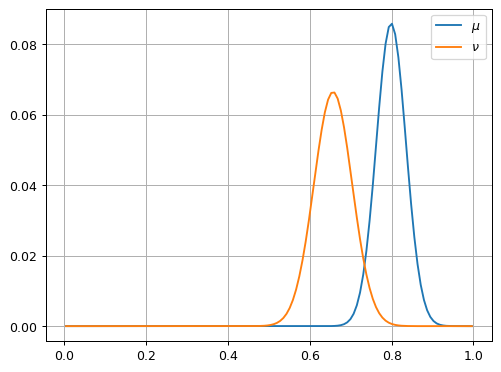

In [11]:
gaussian_problem0, gaussian_problem0_analytic = gaussian_problems[4]
gaussian_mu0, gaussian_nu0 = gaussian_problem0.get_marginals()
_, gaussian_mu0_density = gaussian_mu0.to_discrete(include_zeros=True)
_, gaussian_nu0_density = gaussian_nu0.to_discrete(include_zeros=True)

plt.plot(grid_axes[0], gaussian_mu0_density, label=r'$\mu$')
plt.plot(grid_axes[0], gaussian_nu0_density, label=r'$\nu$')
plt.grid()
plt.legend()

In [12]:
stepsize = 4/jnp.maximum(gaussian_mu0_density.max(), gaussian_nu0_density.sum())
stepsize_lower_bound = 0.01
maxiterations = 300
tolerance = 1e-4
error_metric = 'h1_psi_relative'
# error_metric = 'h1_psi'

results = backnforth_sqeuclidean_nd(
    mu=gaussian_mu0_density,
    nu=gaussian_nu0_density,
    coordinates=grid_axes,
    stepsize=stepsize,
    maxiterations=maxiterations,
    tolerance=tolerance,
    progressbar=True,
    monge_map_fn=monge_map_cic_from_psi_nd,
    pushforward_fn=cic_pushforward_nd,
    stepsize_lower_bound=stepsize_lower_bound,
    error_metric=error_metric,
)
_wait_jax_finish(results)

print(f"Returned keys evailable: {list(results.keys())}")

[0] error = inf; dual = 0.004238038844836103;
[1] error = 0.9633031932391298; dual = 0.0042785626722177846;
[2] error = 1.3746854656676257; dual = 0.004307571455801096;
[3] error = 1.319622319107014; dual = 0.004327007382270889;
[4] error = 1.018145843468661; dual = 0.00434013253059051;
[5] error = 0.7476341956670184; dual = 0.00434944078414723;
[6] error = 0.5809557903881306; dual = 0.004356379304169638;
[7] error = 0.48288889517452993; dual = 0.004361817698396236;
[8] error = 0.4257886124509041; dual = 0.004366255975731948;
[9] error = 0.3697546371754424; dual = 0.00437000085849519;
[10] error = 0.3266473880606748; dual = 0.00437319202257101;
[11] error = 0.3001782324719669; dual = 0.004376005417193058;
[12] error = 0.27993852627998944; dual = 0.004378487004422573;
[13] error = 0.2599220370342561; dual = 0.004380726926014301;
[14] error = 0.24401986903318582; dual = 0.004382758599051565;
[15] error = 0.22862327041593156; dual = 0.0043846074879613966;
[16] error = 0.22284860536254908;

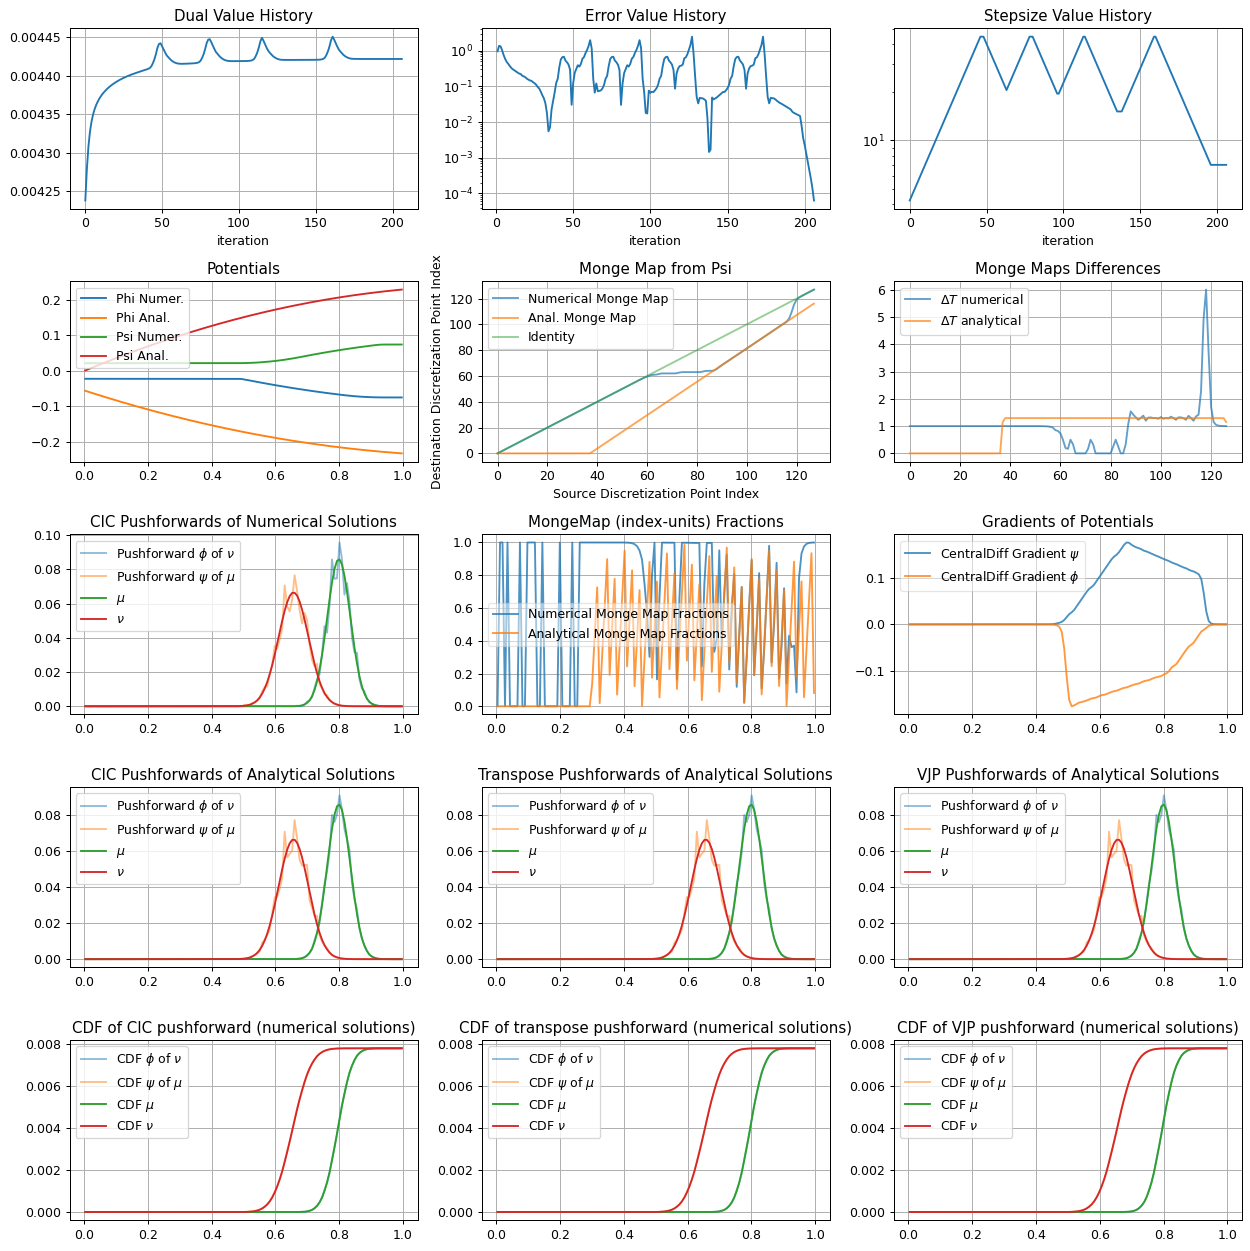

In [13]:
iters = results['iterations']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(14, 14))
[ax.grid() for axxss in axs for ax in axxss]

axs[0][0].plot(results['dual_history'][:iters], label='Dual')
axs[0][0].set_xlabel('iteration')
axs[0][0].set_title('Dual Value History')
axs[0][1].plot(results['errors'][:iters], label='Error')
axs[0][1].set_yscale('log')
axs[0][1].set_xlabel('iteration')
axs[0][1].set_title('Error Value History')
axs[0][2].plot(results['sigma_history'][:iters], label='Stepsize')
axs[0][2].set_yscale('log')
axs[0][2].set_xlabel('iteration')
axs[0][2].set_title('Stepsize Value History')

# --- POTENTIALS ---
axs[1][0].plot(grid_axes[0], results['phi'], label='Phi Numer.')
axs[1][0].plot(grid_axes[0], gaussian_problem0_analytic['phi'], label='Phi Anal.')
# axs[1][0].set_title('Potentials Phi')
# axs[1][0].legend()
axs[1][0].plot(grid_axes[0], results['psi'], label='Psi Numer.')
axs[1][0].plot(grid_axes[0], gaussian_problem0_analytic['psi'], label='Psi Anal.')
# axs[1][0].set_title('Potentials Psi')
axs[1][0].set_title('Potentials')
axs[1][0].legend()

# --- MONGE MAPS ---
monge_map_psi = monge_map_cic_from_psi_nd(results['psi']).reshape((gaussian_params['n_points'],))
monge_map_psi_anal = monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']).reshape((gaussian_params['n_points'],))

axs[1][1].plot(monge_map_psi, alpha=0.7, label='Numerical Monge Map')
axs[1][1].plot(monge_map_psi_anal, alpha=0.7, label='Anal. Monge Map')
axs[1][1].plot(jnp.arange(len(monge_map_psi)), alpha=0.5, label='Identity')
axs[1][1].set_xlabel('Source Discretization Point Index')
axs[1][1].set_ylabel('Destination Discretization Point Index')
axs[1][1].set_title('Monge Map from Psi')
axs[1][1].legend()

diff_monge_numer = monge_map_psi[1:] - monge_map_psi[:-1]
diff_monge_anal = monge_map_psi_anal[1:] - monge_map_psi_anal[:-1]
axs[1][2].plot(diff_monge_numer, alpha=0.7, label='$\\Delta T$ numerical')
axs[1][2].plot(diff_monge_anal, alpha=0.7, label='$\\Delta T$ analytical')
axs[1][2].set_title('Monge Maps Differences')
axs[1][2].legend()

# -------------------------------
# -------- PUSHFORWARDS ---------
# -------------------------------
pushforwards_opacity = 0.5

rho_numer_phi = cic_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = cic_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))

axs[2][0].plot(grid_axes[0], rho_numer_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[2][0].plot(grid_axes[0], rho_numer_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[2][0].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[2][0].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[2][0].legend()
axs[2][0].set_title('CIC Pushforwards of Numerical Solutions')

# rho_numer_phi = ngp_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
# rho_numer_psi = ngp_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
# axs[2][1].plot(grid_axes[0], rho_numer_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
# axs[2][1].plot(grid_axes[0], rho_numer_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
# axs[2][1].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
# axs[2][1].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
# axs[2][1].legend()
# axs[2][1].set_title('NGP Pushforwards of Numerical Solutions')

# rho_numer_phi = binning_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
# rho_numer_psi = binning_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
# axs[2][2].plot(grid_axes[0], rho_numer_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
# axs[2][2].plot(grid_axes[0], rho_numer_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
# axs[2][2].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
# axs[2][2].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
# axs[2][2].legend()
# axs[2][2].set_title('Binning Pushforwards of Numerical Solutions')

# instead of the pushforwards above lets plot some other debugging information

grad_psi_central = _central_gradient_nd(results['psi']).reshape(-1)
grad_phi_central = _central_gradient_nd(results['phi']).reshape(-1)
# grad_psi_lanczos = lanczos_gradient_nd(results['psi']).reshape(-1)
# grad_phi_lanczos = lanczos_gradient_nd(results['phi']).reshape(-1)
axs[2][2].plot(grid_axes[0], grad_psi_central, alpha=0.8, label='CentralDiff Gradient $\\psi$')
axs[2][2].plot(grid_axes[0], grad_phi_central, alpha=0.8, label='CentralDiff Gradient $\\phi$')
# axs[2][2].plot(grid_axes[0], grad_psi_lanczos, alpha=0.8, label='Lanczos Gradient $\\psi$')
# axs[2][2].plot(grid_axes[0], grad_phi_lanczos, alpha=0.8, label='Lanczos Gradient $\\phi$')
axs[2][2].legend(framealpha=0.5, fancybox=True)
axs[2][2].set_title('Gradients of Potentials')


def get_frac_from_monge(monge_map: jnp.ndarray, d: int = 1) -> jnp.ndarray:
    shape = monge_map.shape
    base = jnp.floor(monge_map).astype(jnp.int32)
    for ax in range(d):
        base_ax = jnp.clip(base[ax], 0, shape[ax] - 2)
        base = base.at[ax].set(base_ax)
    frac = monge_map - base.astype(jnp.float32)  # Now frac guaranteed in [0,1)
    return frac

monge_map_psi = monge_map_cic_from_psi_nd(results['psi']).reshape((gaussian_params['n_points'],))
monge_map_psi_anal = monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']).reshape((gaussian_params['n_points'],))
monge_numer_fractions = get_frac_from_monge(monge_map_psi)
monge_anal_fractions = get_frac_from_monge(monge_map_psi_anal)
axs[2][1].plot(grid_axes[0], monge_numer_fractions, alpha=0.8, label='Numerical Monge Map Fractions')
axs[2][1].plot(grid_axes[0], monge_anal_fractions, alpha=0.8, label='Analytical Monge Map Fractions')
# axs[2][1].grid()
axs[2][1].legend(framealpha=0.5, fancybox=True)
axs[2][1].set_title('MongeMap (index-units) Fractions')

# -------------------------------
# --- ANALYTICAL PUSHFORWARDS ---
# -------------------------------
rho_anal_phi = cic_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['phi']))
rho_anal_psi = cic_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']))
axs[3][0].plot(grid_axes[0], rho_anal_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[3][0].plot(grid_axes[0], rho_anal_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[3][0].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[3][0].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[3][0].legend()
axs[3][0].set_title('CIC Pushforwards of Analytical Solutions')

rho_anal_phi = cic_pushforward_via_transpose(gaussian_nu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['phi']))
rho_anal_psi = cic_pushforward_via_transpose(gaussian_mu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']))
axs[3][1].plot(grid_axes[0], rho_anal_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[3][1].plot(grid_axes[0], rho_anal_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[3][1].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[3][1].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[3][1].legend()
axs[3][1].set_title('Transpose Pushforwards of Analytical Solutions')

rho_anal_phi = cic_pushforward_via_vjp(gaussian_nu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['phi']))
rho_anal_psi = cic_pushforward_via_vjp(gaussian_mu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']))
axs[3][2].plot(grid_axes[0], rho_anal_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[3][2].plot(grid_axes[0], rho_anal_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[3][2].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[3][2].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[3][2].legend()
axs[3][2].set_title('VJP Pushforwards of Analytical Solutions')

# ---- CDF FUNCTIONS ----
mu_cdf = jnp.cumsum(gaussian_mu0_density) * (grid_axes[0][1] - grid_axes[0][0])
nu_cdf = jnp.cumsum(gaussian_nu0_density) * (grid_axes[0][1] - grid_axes[0][0])

rho_numer_phi = cic_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = cic_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
rho_numer_phi_cdf = jnp.cumsum(rho_numer_phi) * (grid_axes[0][1] - grid_axes[0][0])
rho_numer_psi_cdf = jnp.cumsum(rho_numer_psi) * (grid_axes[0][1] - grid_axes[0][0])
axs[4][0].plot(grid_axes[0], rho_numer_phi_cdf, alpha=pushforwards_opacity, label='CDF $\\phi$ of $\\nu$')
axs[4][0].plot(grid_axes[0], rho_numer_psi_cdf, alpha=pushforwards_opacity, label='CDF $\\psi$ of $\\mu$')
axs[4][0].plot(grid_axes[0], mu_cdf, label='CDF $\\mu$')
axs[4][0].plot(grid_axes[0], nu_cdf, label='CDF $\\nu$')
axs[4][0].legend()
axs[4][0].set_title('CDF of CIC pushforward (numerical solutions)')

rho_numer_phi = cic_pushforward_via_transpose(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = cic_pushforward_via_transpose(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
rho_numer_phi_cdf = jnp.cumsum(rho_numer_phi) * (grid_axes[0][1] - grid_axes[0][0])
rho_numer_psi_cdf = jnp.cumsum(rho_numer_psi) * (grid_axes[0][1] - grid_axes[0][0])
axs[4][1].plot(grid_axes[0], rho_numer_phi_cdf, alpha=pushforwards_opacity, label='CDF $\\phi$ of $\\nu$')
axs[4][1].plot(grid_axes[0], rho_numer_psi_cdf, alpha=pushforwards_opacity, label='CDF $\\psi$ of $\\mu$')
axs[4][1].plot(grid_axes[0], mu_cdf, label='CDF $\\mu$')
axs[4][1].plot(grid_axes[0], nu_cdf, label='CDF $\\nu$')
axs[4][1].legend()
axs[4][1].set_title('CDF of transpose pushforward (numerical solutions)')

rho_numer_phi = cic_pushforward_via_vjp(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = cic_pushforward_via_vjp(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
rho_numer_phi_cdf = jnp.cumsum(rho_numer_phi) * (grid_axes[0][1] - grid_axes[0][0])
rho_numer_psi_cdf = jnp.cumsum(rho_numer_psi) * (grid_axes[0][1] - grid_axes[0][0])
axs[4][2].plot(grid_axes[0], rho_numer_phi_cdf, alpha=pushforwards_opacity, label='CDF $\\phi$ of $\\nu$')
axs[4][2].plot(grid_axes[0], rho_numer_psi_cdf, alpha=pushforwards_opacity, label='CDF $\\psi$ of $\\mu$')
axs[4][2].plot(grid_axes[0], mu_cdf, label='CDF $\\mu$')
axs[4][2].plot(grid_axes[0], nu_cdf, label='CDF $\\nu$')
axs[4][2].legend()
axs[4][2].set_title('CDF of VJP pushforward (numerical solutions)')

fig.tight_layout()